# Baseline classifier version 1

This is an old version of the baseline classifier that was replcaced by Basic_two.ipynb

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import seaborn as sns
from PIL import Image

import torch

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

import warnings
warnings.filterwarnings('ignore')

from torchtnt.framework.fit import fit
from torchtnt.framework.predict import predict
from torchtnt.framework.unit import TrainUnit, EvalUnit, PredictUnit

W0213 20:55:36.434000 26612 torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


In [4]:
path_to_files = 'flowers'

d = {'name': [], 'path': []}

for label in os.listdir(path_to_files):
    path_to_class_folder = os.path.join(path_to_files, label)
    for file_name in os.listdir(path_to_class_folder):
        path_to_img = os.path.join(path_to_class_folder, file_name)
        
        d['name'].append(label)
        d['path'].append(path_to_img)
        
data = pd.DataFrame(data=d)
print(data.shape)
data.head()

(15740, 2)


,name,path
0,astilbe,flowers\astilbe\10091895024_a2ea04cda6_c.jpg
1,astilbe,flowers\astilbe\1033455028_f0c6518ec9_c.jpg
2,astilbe,flowers\astilbe\10373087134_927b53fb9f_c.jpg
3,astilbe,flowers\astilbe\1052212431_4963309d03_c.jpg
4,astilbe,flowers\astilbe\1052219251_d03970e956_c.jpg


In [5]:
data['name'] = data['name'].str.replace('_',' ')

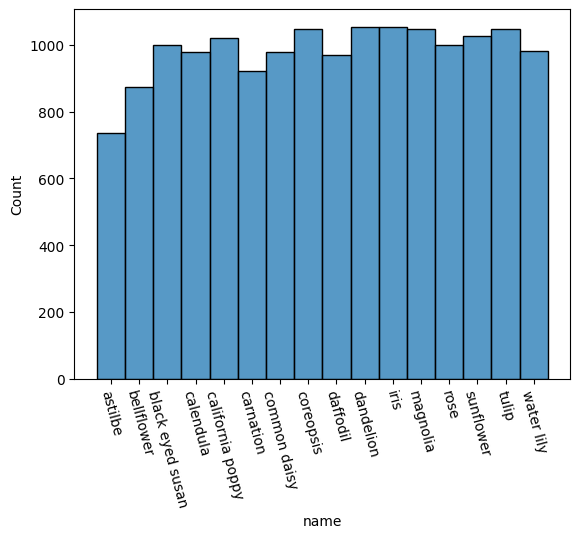

In [6]:
sns.histplot(data, x='name')
plt.xticks(rotation=-75)
None

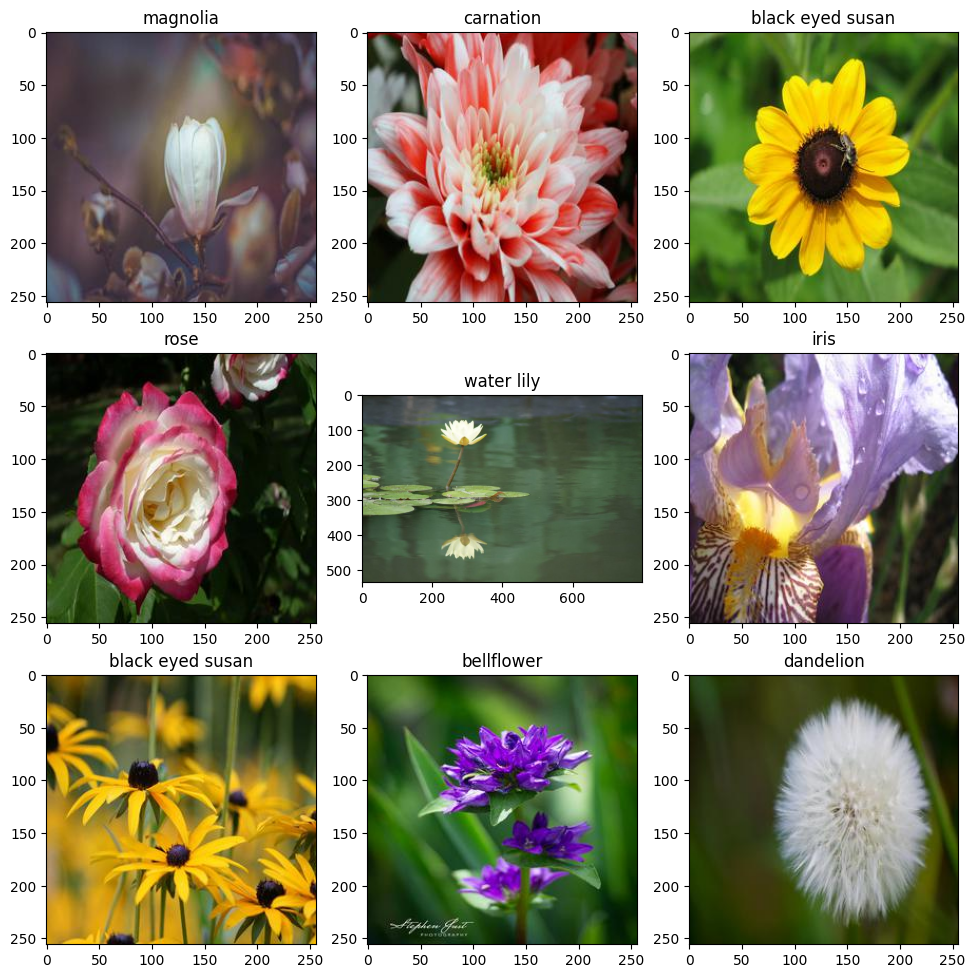

In [8]:
idx = np.random.randint(0, 15740, 9)

axs = plt.subplots(ncols=3, nrows=3, figsize=(10, 10))[1].flatten()

for i, ax in zip(idx, axs):
    obj = data.iloc[i]
    
    img = np.array(Image.open(obj['path']))
    ax.imshow(img)
    ax.set_title(obj['name'])
    
plt.tight_layout(pad=1.5, w_pad=0.4, h_pad=0.4)
plt.show()

In [9]:
encoder = LabelEncoder()

data['label'] = encoder.fit_transform(data['name'])

In [10]:
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import v2

class FlowerDataset(Dataset):
    def __init__(self, dataframe, mode='train'):
        if mode not in ['train', 'testval']:
            raise ValueError(f'Not correct mode value {mode}, availabel modes train or testval')
        
        self._df = dataframe
        self._mode = mode
        self._len = dataframe.shape[0]
        
        self._transforms = {'train': v2.Compose([v2.ToPILImage(),
                                                 v2.Resize(size=(64, 64)),
                                                 v2.RandomRotation(degrees=(-15, 15)),
                                                 v2.RandomHorizontalFlip(p=0.5),
                                                 v2.ToTensor(),
                                                 v2.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
                                               ]),
                           'testval': v2.Compose([v2.ToPILImage(),
                                                  v2.Resize(size=(64, 64)),
                                                  v2.ToTensor(),
                                                  v2.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
                                                 ])
                          }
        
        
    def __len__(self):
        return self._len
    
    
    def load_img(self, path):
        return np.array(Image.open(path))
    
    
    def __getitem__(self, index):
        obj = self._df.iloc[index]
        
        img = self.load_img(obj['path'])
        
        x = self._transforms[self._mode](img)
        y = obj['label']
        
        return x, y

In [11]:
flowers_groups = data.groupby('name')


train_dataframe = pd.DataFrame()
test_dataframe = pd.DataFrame() 

percent_data_to_train = 0.8


for name in flowers_groups.groups.keys():
    group = flowers_groups.get_group(name)
    size = group.shape[0]
    train_size = int(size * percent_data_to_train)
    
    train_dataframe = pd.concat(
        [train_dataframe, group.iloc[0:train_size]],
        ignore_index=True)
    
    test_dataframe = pd.concat(
        [test_dataframe, group.iloc[train_size:size]],
        ignore_index=True)

In [12]:
train_dataframe = train_dataframe.sample(frac=1).reset_index(drop=True)
test_dataframe = test_dataframe.sample(frac=1).reset_index(drop=True)

train_dataset = FlowerDataset(train_dataframe, mode='train')
test_dataset = FlowerDataset(test_dataframe, mode='testval')

train_dataloader = DataLoader(train_dataset, batch_size=256, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=256, shuffle=False)

In [14]:
from typing import Tuple
from IPython import display

Batch = Tuple[torch.tensor, torch.tensor]

class ModelUnit(TrainUnit[Batch], EvalUnit[Batch]):
    def __init__(self, 
                model,
                loss_function,
                optimizer,
                lr_scheduler=None,
                device='cpu',
                save_best_weights=True,
                path_to_save_weights='',
                weights_file_name='bestweights.pth'):
        super().__init__()
        self.model = model
        self.loss_function = loss_function
        self.optimizer = optimizer
        self.lr_scheduler = lr_scheduler
        self.device = device
        
        self.save_best_w = save_best_weights
        self.path_to_save = path_to_save_weights
        self.file_name = weights_file_name
        
        self.loss_train_history = []
        self.accuracy_history = []
        self.loss_train = []
        self.accuracy = []
        
        self.best_acc = -1
        
    def on_train_start(self, state):
        self.model.to(self.device)
    
    def train_step(self, state, data):
        inputs, labels = data
        
        inputs = inputs.to(self.device)
        labels = labels.to(self.device)
        
        outputs = self.model(inputs)
        loss = self.loss_function(outputs, labels)
        loss.backward()
        
        self.optimizer.step()
        self.optimizer.zero_grad()
        self.loss_train.append(loss.item())
            
        
    def on_train_epoch_end(self, state):
        if self.lr_scheduler is not None:
            self.lr_scheduler.step()
        
        mean_loss_per_epoch = np.array(self.loss_train).mean()
        self.loss_train_history.append(mean_loss_per_epoch)
        
        self.loss_train.clear()
    
    def on_eval_epoch_start(self, state):
        print('evaluation')
    
    def eval_step(self, state, data):
        inputs, labels = data
        
        inputs = inputs.to(self.device)
        labels = labels.to(self.device)
        
        outputs = self.model(inputs)
        
        pred = torch.argmax(outputs, 1)
        acc = torch.sum(pred == labels.data)
        self.accuracy.append(acc.item()/pred.size(0))
        
    def on_eval_epoch_end(self, state):
        eval_accuracy_per_epoch = np.array(self.accuracy).mean()
        
        self.accuracy_history.append(eval_accuracy_per_epoch)
        self.accuracy.clear()
        
        # save the weights that gave the best accuracy
        if self.save_best_w and self.accuracy_history[-1] > self.best_acc:
            path_to_save = os.path.join(self.path_to_save, self.file_name)
            torch.save(self.model.state_dict(), path_to_save)
            self.best_acc = self.accuracy_history[-1]
        
        display.clear_output(wait=True)
        num_epochs = self.train_progress._num_epochs_completed
        print(f"epoch: {num_epochs}")
        
        axs = plt.subplots(ncols=2, nrows=1, figsize=(12, 8))[1].flatten()
        
        size1 = len(self.loss_train_history)
        axs[0].plot(range(size1), self.loss_train_history)
        axs[0].set_xlabel('epoch')
        axs[0].set_ylabel('loss function')
        
        size2 = len(self.accuracy_history)
        axs[1].plot(range(size2), self.accuracy_history)
        axs[1].set_xlabel('epoch')
        axs[1].set_ylabel('accuracy')
        
        plt.tight_layout(w_pad=0.5, h_pad=0.5)
        plt.show()

In [17]:
from torch.optim import AdamW
from torch.nn import CrossEntropyLoss
from torch.optim.lr_scheduler import ExponentialLR

from torchvision.models import densenet201, DenseNet201_Weights

model = densenet201(weights=DenseNet201_Weights)
model.classifier = torch.nn.Linear(in_features=1920, out_features=16, bias=True)

loss_function = CrossEntropyLoss()
optimizer = AdamW(model.parameters())
scheduler = ExponentialLR(optimizer, gamma=0.9)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

param = {'path_to_save_weights': '',
        'weights_file_name': 'bestweights.pth'}


unit = ModelUnit(model, loss_function, optimizer, lr_scheduler=scheduler, device=DEVICE, **param)

epoch: 80


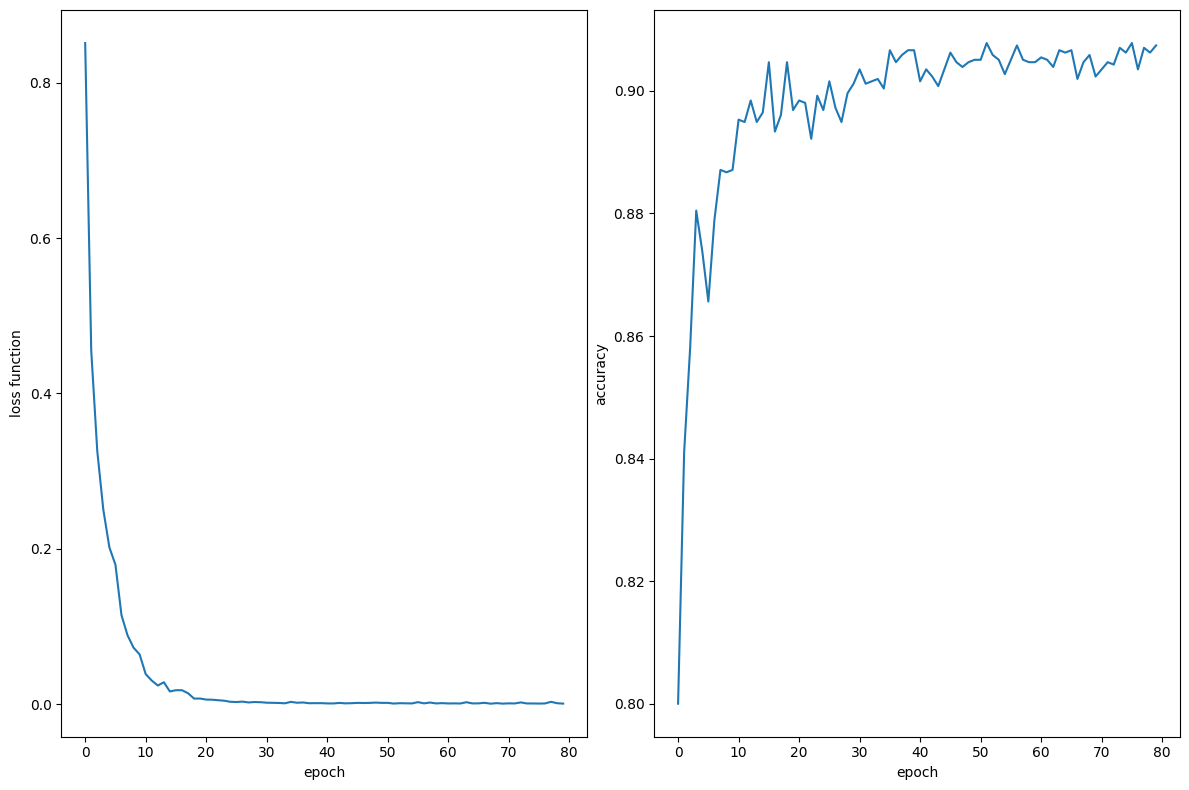

In [18]:
fit_param = {'max_epochs': 80,
            'max_eval_steps_per_epoch': 10,
            'evaluate_every_n_epochs': 1}


fit(unit, train_dataloader=train_dataloader, eval_dataloader=test_dataloader, **fit_param)